In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# 자전거 데이터 캐글
https://www.kaggle.com/c/bike-sharing-demand/overview

In [5]:
# 데이터 불러오기
bike_df = pd.read_csv("./data/bike_train.csv")
bike_df.head(5)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [6]:
# 문자열을 datetime 타입으로 변경.
bike_df['datetime'] = bike_df.datetime.apply(pd.to_datetime)

from datetime import datetime
bike_df['month'] = bike_df['datetime'].dt.month
bike_df['hour'] = bike_df['datetime'].dt.hour
bike_df['dayofweek'] = bike_df['datetime'].dt.dayofweek
bike_df.head(3)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,5


In [7]:
drop_columns = ['datetime','casual','registered']

bike_df = bike_df.drop(drop_columns, axis = 1)
print(bike_df)
# 필요없는 컬럼 삭제하기

       season  holiday  workingday  weather   temp   atemp  humidity  \
0           1        0           0        1   9.84  14.395        81   
1           1        0           0        1   9.02  13.635        80   
2           1        0           0        1   9.02  13.635        80   
3           1        0           0        1   9.84  14.395        75   
4           1        0           0        1   9.84  14.395        75   
...       ...      ...         ...      ...    ...     ...       ...   
10881       4        0           1        1  15.58  19.695        50   
10882       4        0           1        1  14.76  17.425        57   
10883       4        0           1        1  13.94  15.910        61   
10884       4        0           1        1  13.94  17.425        61   
10885       4        0           1        1  13.12  16.665        66   

       windspeed  count  month  hour  dayofweek  
0         0.0000     16      1     0          5  
1         0.0000     40      1     

In [8]:
# EDA를 위한 시각화하기
# 조건에 따른 대여량 시각화

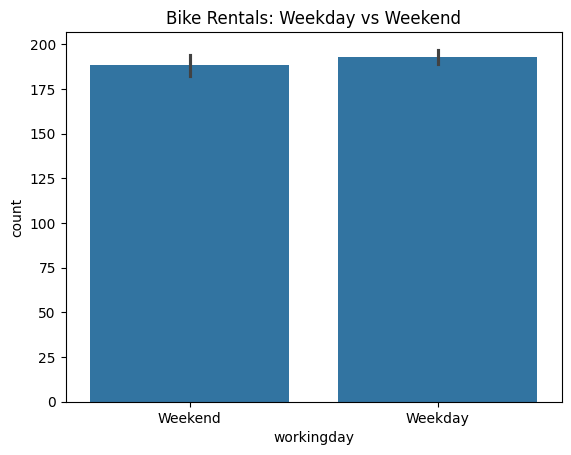

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(data=bike_df, x='workingday', y='count')

plt.xticks([0,1], ['Weekend','Weekday'])
plt.title('Bike Rentals: Weekday vs Weekend')
plt.show()

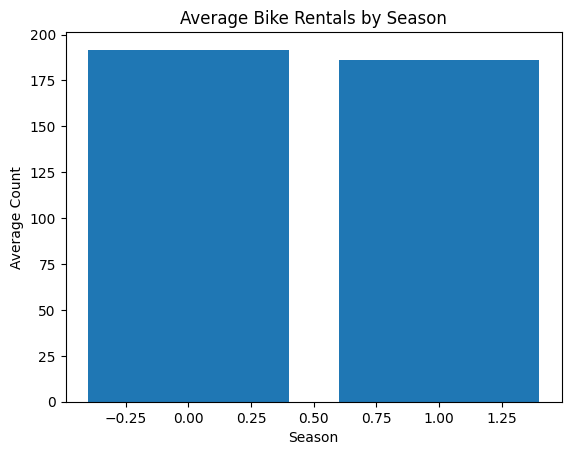

In [10]:
import matplotlib.pyplot as plt

season_count = bike_df.groupby('holiday')['count'].mean()

plt.bar(season_count.index, season_count.values)

plt.xlabel('Season')
plt.ylabel('Average Count')
plt.title('Average Bike Rentals by Season')

plt.show()

In [ ]:
season, month, temp



In [11]:
X = bike_df[['season','holiday','workingday', 'weather','atemp', 'humidity', 'windspeed', 'month', 'hour', 'dayofweek']]
y = bike_df['count']

In [12]:
# 훈련세트/테스트세트 분할

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, train_size=0.7, random_state=42)
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)

(7620, 10) (3266, 10) (7620,) (3266,)


In [13]:
# 모델 생성 및 훈련

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train1, y_train1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
# 수치형변수 스케일링 
pred = model.predict(X_test1)

from sklearn.metrics import mean_squared_error, r2_score


print(f'MSE: {mean_squared_error(y_test1, pred):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test1, pred):.2f}') # 결정계수(R2)



MSE: 21800.15
r2_score: 0.33


In [16]:
# 범주형변수 원핫인코딩 

cf_columns = [
    'season',
    'holiday',
    'workingday',
    'weather',
    'atemp',
    'humidity',
    'windspeed',
    'month',
    'hour',
    'dayofweek'
]
X_encoded = pd.get_dummies(X, columns=cf_columns)
print(X_encoded)

       season_1  season_2  season_3  season_4  holiday_0  holiday_1  \
0          True     False     False     False       True      False   
1          True     False     False     False       True      False   
2          True     False     False     False       True      False   
3          True     False     False     False       True      False   
4          True     False     False     False       True      False   
...         ...       ...       ...       ...        ...        ...   
10881     False     False     False      True       True      False   
10882     False     False     False      True       True      False   
10883     False     False     False      True       True      False   
10884     False     False     False      True       True      False   
10885     False     False     False      True       True      False   

       workingday_0  workingday_1  weather_1  weather_2  ...  hour_21  \
0              True         False       True      False  ...    False   
1

In [17]:
# 최종 훈련 테스트 데이터 만들어서 모델 생성 및 훈련
# 훈련세트/테스트세트 분할

from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_encoded, y, train_size=0.7, random_state=42)
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)


from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train1, y_train1)

(7620, 232) (3266, 232) (7620,) (3266,)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
pred = model.predict(X_test1)

from sklearn.metrics import mean_squared_error, r2_score


print(f'MSE: {mean_squared_error(y_test1, pred):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test1, pred):.2f}') # 결정계수(R2)


MSE: 12399.32
r2_score: 0.62


In [19]:
from sklearn.linear_model import LinearRegression

model2 = LinearRegression()
model2.fit(X_train1,y_train1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
import pandas as pd
test_df = pd.read_csv('./data/bike_test.csv')

test_df['datetime'] = pd.to_datetime(test_df['datetime'])

test_df['month'] = test_df['datetime'].dt.month
test_df['hour'] = test_df['datetime'].dt.hour
test_df['dayofweek'] = test_df['datetime'].dt.dayofweek
print(test_df)

                datetime  season  holiday  workingday  weather   temp   atemp  \
0    2011-01-20 00:00:00       1        0           1        1  10.66  11.365   
1    2011-01-20 01:00:00       1        0           1        1  10.66  13.635   
2    2011-01-20 02:00:00       1        0           1        1  10.66  13.635   
3    2011-01-20 03:00:00       1        0           1        1  10.66  12.880   
4    2011-01-20 04:00:00       1        0           1        1  10.66  12.880   
...                  ...     ...      ...         ...      ...    ...     ...   
6488 2012-12-31 19:00:00       1        0           1        2  10.66  12.880   
6489 2012-12-31 20:00:00       1        0           1        2  10.66  12.880   
6490 2012-12-31 21:00:00       1        0           1        1  10.66  12.880   
6491 2012-12-31 22:00:00       1        0           1        1  10.66  13.635   
6492 2012-12-31 23:00:00       1        0           1        1  10.66  13.635   

      humidity  windspeed  

In [23]:
cat_cols = [
'season',
'weather',
'month',
'hour',
'dayofweek',
'holiday',
'workingday'
]

test_encoded = pd.get_dummies(
    test_df,
    columns=cat_cols
)

test_encoded = test_encoded.reindex(
    columns=X_train1.columns,
    fill_value=0
)

In [24]:
count_pred = model.predict(test_encoded)

print(f"첫 예상 대여 수: {count_pred[0]:.0f}대")

첫 예상 대여 수: 4대
